<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 13/13 — Export ผลรวมให้แดชบอร์ด (CIT Forecast Export)

**สถานะ:** ✅ ใช้งานจริง — `CHAIN[12]` ใน `pipeline/run_all.py` (notebook สุดท้ายใน chain หลัก),
ตามด้วย 14 post-processor script + 2 notebook เพิ่มเติม (`14_tam_constraint_analysis.ipynb`,
`16_cleaning_plan_optimization.ipynb`)

**ตอบคำถามอะไร:** รวบผลจาก step 7 (time-to-clean) / step 11 (SHAP) / step 10 (model metrics)
พยากรณ์ล่วงหน้า 182 วัน แล้ว export JSON หลักเกือบทั้งหมดให้แดชบอร์ด

**มาจาก (Sources):** `hx_ranking.json`'s `priority_score` **ไม่ได้คำนวณใน notebook นี้** — เป็น passthrough
ของ `hx_Q_cleaning_priority_v2.csv` (step 11) ซึ่งตัวมันเองก็ passthrough จาก step 8's
`engineering_priority_score` อีกที (ห่วงโซ่: step 8 → step 11 → step 13 → `hx_ranking.json`, ค่าเดียวกันตลอด)
สำหรับ ranking หลักที่ใช้ตัดสินใจจริง ให้ดู `engineering_priority.json`
(step 8 → `pipeline/export_engineering_priority.py` โดยตรง, ไม่ผ่าน step 11/13) — สองไฟล์นี้ควรมีค่าเท่ากัน
เสมอถ้ามาจาก pipeline run เดียวกัน แต่ **partial rerun (เช่น `--only 13`) ทำให้ไม่ตรงกันได้ถ้าไม่ได้รัน step 8 ใหม่**
(ดู `pipeline/export_engineering_priority.py`'s consistency check)

**Input:** `Time_To_Clean_Prediction.csv` (step 7), `hx_Q_cleaning_priority_v2.csv` (step 11),
`Model_Comparison_Metrics.csv` (step 10)

**Output:** `forecast_6mo.json`, `hx_ranking.json`, `cleaning_recommendations.json` → เข้าแดชบอร์ดตรง ๆ
(`model_metrics.json` เขียนแยกโดย `pipeline/gen_honest_metrics.py` เท่านั้น ไม่ใช่ notebook นี้)

**แดชบอร์ด:** แท็บ "ภาพรวม & P&ID" เป็นหลัก (ร่วมกับ step 8 และ `16_cleaning_plan_optimization.ipynb`)

**Requirements ที่เกี่ยวข้อง:** Business Problem §1 (decision horizon 182 วัน — ยังไม่ปิดว่า horizon
ตัดสินใจหลักคือกี่วัน, ดู open items ท้าย `docs/03`)

**Next:** หลังจาก step นี้ ตามด้วย post-processor 14 ตัว (`pipeline/*.py`) + notebook 14/16 — ดูลำดับเต็มที่
`docs/ANALYSIS_PIPELINE_GUIDE.md` §1 แถวที่ 14-27

---

# Six-Month Forecast & Dashboard Export

Answers the project's core question directly: **which HX should be cleaned, and
when** — by linearly extrapolating each HX's fouling-deviation signal 182 days
(~6 months) forward from `Data/Time_To_Clean_Prediction.csv`, then exporting
everything the static HTML dashboard needs as JSON.

**No new detection/threshold logic is introduced here** — `Time_To_Clean_Prediction.csv`
(built in `07_time_to_clean_prediction.ipynb`) already contains a validated
per-HX deviation, threshold, and fouling rate; this notebook only projects that
trend forward and packages the result for the dashboard.

Sections:
1. Load `Time_To_Clean_Prediction.csv`, `hx_Q_cleaning_priority_v2.csv` (from `6b`),
   `Model_Comparison_Metrics.csv` (from `6a`)
2. 182-day linear extrapolation per HX
3. Final cleaning-recommendation table (HX, priority rank, projected trigger date)
4. Plot: 6-month forecast for top-priority HX
5. Export `dashboard/data/*.json`

## 0. Imports & Configuration

In [1]:
import json as jsonlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

DATA_DIR      = Path(r'C:\Desktop\Bangchak Internship 2026\Data')
REPO_ROOT     = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
OUT_DIR       = REPO_ROOT / 'outputs'
FIG_DIR       = REPO_ROOT / 'figures' / 'forecast_6mo'
DASHBOARD_DIR = REPO_ROOT / 'dashboard' / 'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_DAYS = 182   # ~6 months look-ahead

---
## 1. Load Inputs

In [2]:
ttc = pd.read_csv(DATA_DIR / 'Time_To_Clean_Prediction.csv')
priority_v2 = pd.read_csv(OUT_DIR / 'hx_Q_cleaning_priority_v2.csv', index_col=0)
model_metrics = pd.read_csv(OUT_DIR / 'Model_Comparison_Metrics.csv')

# Reference 'as of' date -- last timestamp in the underlying process data, same
# basis Time_To_Clean_Prediction.csv itself was built from.
last_date = pd.read_csv(DATA_DIR / 'Process_information_cleaned.csv',
                         index_col='Timestamp', parse_dates=True).index.max()

print(f'Time_To_Clean_Prediction.csv: {ttc.shape[0]} HX rows')
print(f'hx_Q_cleaning_priority_v2.csv: {priority_v2.shape[0]} HX rows')
print(f'As-of date: {last_date.date()}')
ttc.head()

Time_To_Clean_Prediction.csv: 15 HX rows
hx_Q_cleaning_priority_v2.csv: 14 HX rows
As-of date: 2026-07-01


,HX,effort_tier,current_deviation,threshold,threshold_source,threshold_confidence,rate_degC_per_day,rate_source,days_to_threshold,beyond_horizon,projected_need_by_date,at_risk_before_tam
0,E101EF,ONLINE_FULL,3851.275700,2847.789612,own_history,medium,3.395806,current_run,0.0,False,2026-07-01 00:00:00.000000000,False
1,E103AB,TAM_ONLY,1241.733055,515.847990,own_history,high,1.944340,current_run,0.0,False,2026-07-01 00:00:00.000000000,True
2,E109AB,TAM_ONLY,464.907260,203.562426,own_history,high,2.936285,current_run,0.0,False,2026-07-01 00:00:00.000000000,True
3,E104,ONLINE_FULL,2307.678756,613.275061,own_history,high,4.125197,current_run,0.0,False,2026-07-01 00:00:00.000000000,False
4,E110ABC,ONLINE_FULL,2369.801292,1243.302739,own_history,medium,2.959877,current_run,0.0,False,2026-07-01 00:00:00.000000000,False


---
## 2. 182-Day Linear Extrapolation per HX

`projected_deviation(t) = current_deviation + rate_kW_per_day * t`

Only HX with a **positive** fouling rate (deviation growing) can cross their
threshold going forward; HX with a flat/negative rate are marked
`beyond_horizon` (consistent with the convention already used in
`Time_To_Clean_Prediction.csv` / `07_time_to_clean_prediction.ipynb`).

In [3]:
forecast_rows = []
forecast_series = {}

for _, row in ttc.iterrows():
    hx = row['HX']
    current_dev = row['current_deviation']
    threshold   = row['threshold']
    rate        = row['rate_kW_per_day']

    days = np.arange(0, HORIZON_DAYS + 1)
    dates = [last_date + pd.Timedelta(days=int(d)) for d in days]
    projected = current_dev + rate * days

    if current_dev >= threshold:
        # Already past trigger as of the as-of date -- due now, not a future projection.
        days_to_cross = 0.0
    elif rate > 0:
        days_to_cross = (threshold - current_dev) / rate
    else:
        days_to_cross = np.nan

    if pd.notna(days_to_cross) and 0 <= days_to_cross <= HORIZON_DAYS:
        trigger_date = last_date + pd.Timedelta(days=float(days_to_cross))
        within_horizon = True
    else:
        trigger_date = pd.NaT
        within_horizon = False

    forecast_series[hx] = {
        'dates': [d.strftime('%Y-%m-%d') for d in dates],
        'projected_deviation': [round(float(v), 3) for v in projected],
        'threshold': float(threshold),
        'current_deviation': float(current_dev),
    }

    forecast_rows.append({
        'HX'                  : hx,
        'effort_tier'         : row['effort_tier'],
        'current_deviation'   : round(current_dev, 3),
        'threshold'           : round(threshold, 3),
        'rate_kW_per_day'     : round(rate, 5),
        'days_to_threshold_6mo': round(days_to_cross, 1) if pd.notna(days_to_cross) else np.nan,
        'projected_clean_date': trigger_date.date().isoformat() if within_horizon else None,
        'at_risk_within_6mo'  : bool(within_horizon or row['days_to_threshold'] == 0),
    })

forecast_df = pd.DataFrame(forecast_rows).sort_values('days_to_threshold_6mo', na_position='last')
print(f'{int(forecast_df["at_risk_within_6mo"].sum())} of {len(forecast_df)} HX projected to need cleaning within 6 months')
forecast_df

9 of 15 HX projected to need cleaning within 6 months


,HX,effort_tier,current_deviation,threshold,rate_degC_per_day,days_to_threshold_6mo,projected_clean_date,at_risk_within_6mo
0,E101EF,ONLINE_FULL,3851.276,2847.790,3.39581,0.0,2026-07-01,True
1,E103AB,TAM_ONLY,1241.733,515.848,1.94434,0.0,2026-07-01,True
2,E109AB,TAM_ONLY,464.907,203.562,2.93629,0.0,2026-07-01,True
3,E104,ONLINE_FULL,2307.679,613.275,4.12520,0.0,2026-07-01,True
4,E110ABC,ONLINE_FULL,2369.801,1243.303,2.95988,0.0,2026-07-01,True
5,E112AB,ONLINE_FULL,2354.911,940.664,0.07701,0.0,2026-07-01,True
6,E113A,SWAP_CAPABLE,2035.846,1609.216,18.76612,0.0,2026-07-01,True
7,E102,ONLINE_FULL,29.978,87.801,0.87881,65.8,2026-09-04,True
8,E107AB,TAM_ONLY,125.295,288.841,1.19725,136.6,2026-11-14,True
9,E101CD,ONLINE_PARTIAL,76.445,466.569,0.73043,534.1,None,False


In [4]:
# --- 80% prediction interval per HX (folded in from the former
#     notebooks/add_forecast_intervals.py post-processor -- that script patched
#     forecast_6mo.json AFTER this notebook wrote it; doing it here means there
#     is exactly one writer of forecast_6mo.json, with the complete schema from
#     the start, matching the fix already applied to the other overwrite chains
#     documented in docs/CURRENT_PIPELINE_MAP.md) ---
#
# The point forecast above is a single deterministic line (current_dev +
# rate*t). A point forecast with no uncertainty over-states confidence.
# Fouling deviation behaves like a drifting/random-walk series, so forecast
# uncertainty grows with the square-root of the horizon:
#   band(t) = z * sigma_daily * sqrt(1 + t / n_fit), z=1.28 -> ~80% interval
# sigma_daily is the residual std (around the CURRENT run's own linear trend,
# not the raw day-to-day diff -- otherwise the cone explodes) computed from
# Q_Deviation_Signal.csv's per-timestamp Q-duty deviation series.

Z_INTERVAL = 1.28  # ~80% band

q_dev = pd.read_csv(DATA_DIR / 'Q_Deviation_Signal.csv', parse_dates=['Timestamp'])

def _interval_fit_stats(hx):
    """Residual std around the CURRENT run's linear deviation trend + run length."""
    d = q_dev[q_dev['HX'] == hx]
    if d.empty or 'run_id' not in d.columns:
        return None, None
    last_run = d['run_id'].dropna().iloc[-1] if d['run_id'].notna().any() else None
    cur = d[d['run_id'] == last_run] if last_run is not None else d.tail(60)
    cur = cur.sort_values('Timestamp')
    dev = cur['deviation'].astype(float).values
    if len(dev) < 8:
        return None, None
    t = np.arange(len(dev), dtype=float)
    b, a = np.polyfit(t, dev, 1)
    resid = dev - (a + b * t)
    return float(np.std(resid)), len(dev)

n_with_interval = 0
for hx, entry in forecast_series.items():
    sigma, n_fit = _interval_fit_stats(hx)
    proj = entry['projected_deviation']
    if sigma is None or not np.isfinite(sigma) or sigma == 0:
        # no reliable fit -> flat 5% band so the chart still shows a cone
        band = [max(0.02 * abs(v), 0.05) * Z_INTERVAL for v in proj]
    else:
        band = [Z_INTERVAL * sigma * np.sqrt(1 + i / max(n_fit, 1)) for i in range(len(proj))]
        n_with_interval += 1
    entry['projected_upper'] = [round(v + b, 3) for v, b in zip(proj, band)]
    entry['projected_lower'] = [round(max(0.0, v - b), 3) for v, b in zip(proj, band)]
    entry['interval_pct'] = 80
    entry['sigma_daily'] = round(sigma, 4) if sigma else None

print(f'Added 80% prediction intervals to {len(forecast_series)} HX '
      f'({n_with_interval} from a fitted current-run residual, rest flat fallback band)')

Added 80% prediction intervals to 15 HX (15 from a fitted current-run residual, rest flat fallback band)


---
## 3. Final Cleaning-Recommendation Table

Combines the SHAP-based priority ranking (`6b`) with the 6-month forecast
(section 2) — this is the direct answer to "which HX, and when."

In [5]:
recommendation = priority_v2[['priority_score', 'cit_shap_importance', 'Q_fouling_rate_abs',
                               'recommended_action']].copy()
recommendation['priority_rank'] = recommendation['priority_score'].rank(ascending=False).astype(int)

fc_indexed = forecast_df.set_index('HX')
recommendation = recommendation.join(
    fc_indexed[['effort_tier', 'projected_clean_date', 'at_risk_within_6mo', 'days_to_threshold_6mo']]
)
recommendation = recommendation.sort_values('priority_rank')

out_path = OUT_DIR / 'Cleaning_Recommendation_Final.csv'
recommendation.to_csv(out_path)
print(f'Saved -> {out_path}')
recommendation.round(3)

Saved -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\outputs\Cleaning_Recommendation_Final.csv


,priority_score,cit_shap_importance,Q_fouling_rate_abs,recommended_action,priority_rank,effort_tier,projected_clean_date,at_risk_within_6mo,days_to_threshold_6mo
HX,,,,,,,,,
E113A,1.000,0.658,5.305,Clean now (past trigger),1,SWAP_CAPABLE,2026-07-01,True,0.0
E112AB,0.929,0.371,1.079,Stable / monitor,2,ONLINE_FULL,2026-07-01,True,0.0
E101AB,0.857,0.289,0.532,Clean now (past trigger),3,ONLINE_FULL,None,False,NaN
E109AB,0.786,0.113,3.431,Clean now (past trigger),4,TAM_ONLY,2026-07-01,True,0.0
E104,0.714,0.294,0.361,Clean now (past trigger),5,ONLINE_FULL,2026-07-01,True,0.0
E108AB,0.643,0.094,0.000,Clean now (past trigger),6,ONLINE_FULL,None,False,NaN
E110ABC,0.571,0.162,0.000,Clean now (past trigger),7,ONLINE_FULL,2026-07-01,True,0.0
E101CD,0.500,0.078,0.467,Stable / monitor,8,ONLINE_PARTIAL,None,False,534.1
E102,0.429,0.107,0.221,Clean now (past trigger),9,ONLINE_FULL,2026-09-04,True,65.8


In [6]:
print('='*70)
print('FINAL CLEANING RECOMMENDATIONS (priority rank + 6-month forecast)')
print('='*70)
for hx, row in recommendation.head(8).iterrows():
    when = row['projected_clean_date'] if pd.notna(row['projected_clean_date']) else row['recommended_action']
    print(f"  #{int(row['priority_rank'])}  {hx:<10}  priority={row['priority_score']:.3f}  "
          f"effort={row['effort_tier']:<26}  clean by: {when}")
print('='*70)

FINAL CLEANING RECOMMENDATIONS (priority rank + 6-month forecast)
  #1  E113A       priority=1.000  effort=SWAP_CAPABLE                clean by: 2026-07-01
  #2  E112AB      priority=0.929  effort=ONLINE_FULL                 clean by: 2026-07-01
  #3  E101AB      priority=0.857  effort=ONLINE_FULL                 clean by: Clean now (past trigger)
  #4  E109AB      priority=0.786  effort=TAM_ONLY                    clean by: 2026-07-01
  #5  E104        priority=0.714  effort=ONLINE_FULL                 clean by: 2026-07-01
  #6  E108AB      priority=0.643  effort=ONLINE_FULL                 clean by: Clean now (past trigger)
  #7  E110ABC     priority=0.571  effort=ONLINE_FULL                 clean by: 2026-07-01
  #8  E101CD      priority=0.500  effort=ONLINE_PARTIAL              clean by: Stable / monitor


---
## 4. Plot: 6-Month Forecast for Top-Priority HX

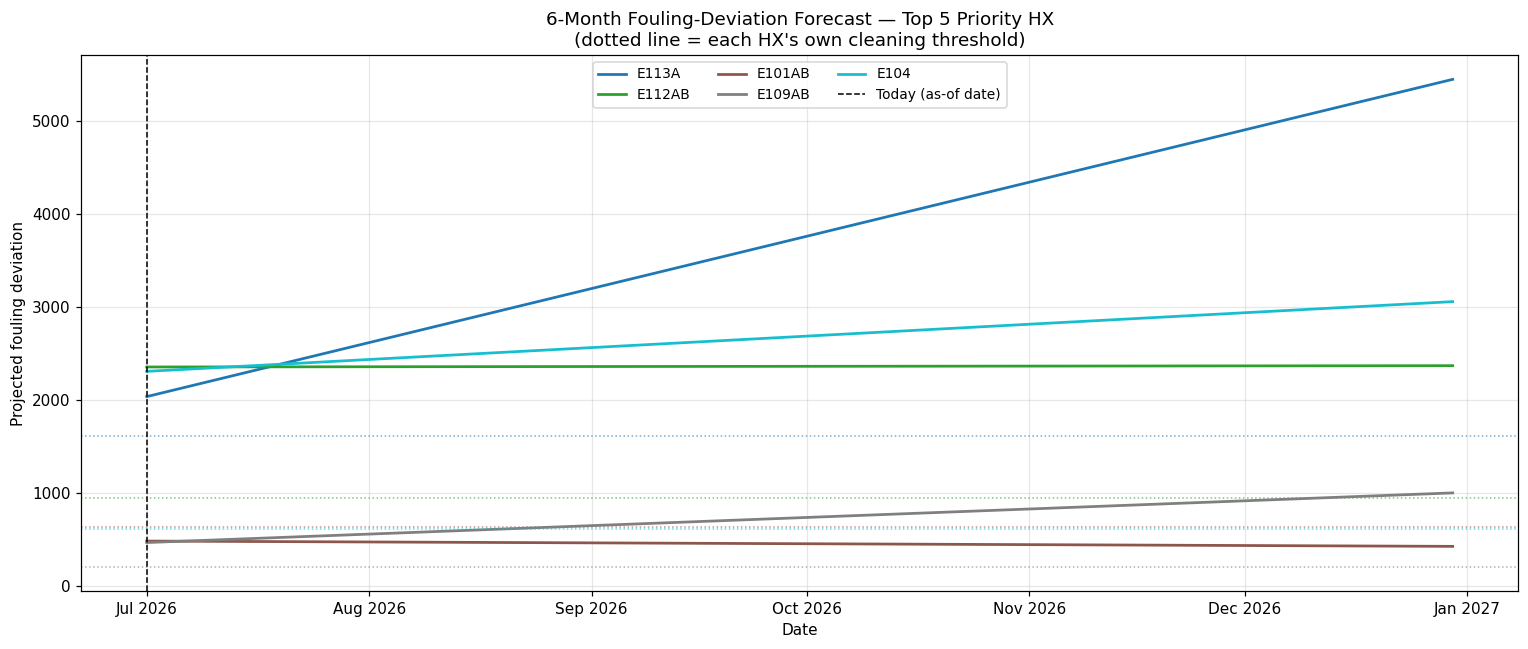

In [7]:
top5 = recommendation.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(top5)))
for hx, color in zip(top5, colors):
    fc = forecast_series[hx]
    dates = pd.to_datetime(fc['dates'])
    ax.plot(dates, fc['projected_deviation'], lw=1.8, color=color, label=f'{hx}')
    ax.axhline(fc['threshold'], color=color, ls=':', lw=1, alpha=0.6)

ax.axvline(last_date, color='black', ls='--', lw=1, label='Today (as-of date)')
ax.set_ylabel('Projected fouling deviation')
ax.set_xlabel('Date')
ax.set_title('6-Month Fouling-Deviation Forecast — Top 5 Priority HX\n(dotted line = each HX\'s own cleaning threshold)')
ax.legend(ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'six_month_forecast_top5.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 5. Export Dashboard Data (`dashboard/data/*.json`)

In [8]:
# hx_ranking.json -- SHAP-based cleaning priority table
hx_ranking = priority_v2.reset_index().rename(columns={'index': 'HX'})
hx_ranking.columns = ['HX'] + list(hx_ranking.columns[1:])
hx_ranking_records = jsonlib.loads(hx_ranking.round(4).to_json(orient='records'))
with open(DASHBOARD_DIR / 'hx_ranking.json', 'w') as f:
    jsonlib.dump(hx_ranking_records, f, indent=2)

# forecast_6mo.json -- per-HX daily projected series, incl. the 80% prediction
# interval computed above (projected_upper/lower/interval_pct/sigma_daily)
with open(DASHBOARD_DIR / 'forecast_6mo.json', 'w') as f:
    jsonlib.dump(forecast_series, f, indent=2)

# NOTE: model_metrics.json is intentionally NOT written here. This notebook's
# Model_Comparison_Metrics.csv (single 80/20 split) looks better than the model
# actually performs out-of-sample -- see docs/project_cit_persistence_finding.
# pipeline/gen_honest_metrics.py is the sole writer of model_metrics.json,
# using walk-forward CV + a persistence baseline instead. It runs as its own
# post-processing step in pipeline/run_all.py (step 1 of the POST list) after
# this notebook.

# cleaning_recommendations.json -- final synthesized table
reco_export = recommendation.reset_index().rename(columns={'index': 'HX'})
reco_records = jsonlib.loads(reco_export.round(4).to_json(orient='records'))
with open(DASHBOARD_DIR / 'cleaning_recommendations.json', 'w') as f:
    jsonlib.dump(reco_records, f, indent=2)

print('Exported dashboard data files:')
for f in sorted(DASHBOARD_DIR.glob('*.json')):
    print(' -', f.name, f'({f.stat().st_size:,} bytes)')

Exported dashboard data files:
 - cit_floor_override.json (27 bytes)
 - clean_baseline_sandbox.json (1,551 bytes)
 - cleaning_history.json (63,969 bytes)
 - cleaning_logistics.json (10,280 bytes)
 - cleaning_plan.json (37,063 bytes)
 - cleaning_recommendations.json (4,946 bytes)
 - cleaning_schedule.json (11,422 bytes)
 - cleaning_schedule_v2.json (22,331 bytes)
 - cost_overrides.json (2 bytes)
 - drivers.json (1,620 bytes)
 - economics.json (13,795 bytes)
 - end_of_run.json (24,677 bytes)
 - engineering_priority.json (17,086 bytes)
 - evidence.json (7,924 bytes)
 - forecast_6mo.json (194,896 bytes)
 - hx_ranking.json (6,714 bytes)
 - hx_timeseries.json (974,779 bytes)
 - model_metrics.json (3,529 bytes)
 - opt_params.json (25 bytes)
 - pfd_topology.json (21,245 bytes)
 - propagation_models.json (38,931 bytes)
 - reliability.json (61,876 bytes)
 - rul.json (3,426 bytes)
 - tam_analysis.json (22,245 bytes)
 - tam_comparison.json (1,707 bytes)


In [9]:
# Validate every exported file is well-formed JSON
for f in sorted(DASHBOARD_DIR.glob('*.json')):
    with open(f) as fh:
        obj = jsonlib.load(fh)
    n = len(obj) if isinstance(obj, list) else len(obj.keys())
    print(f'{f.name}: OK ({n} top-level entries)')

cit_floor_override.json: OK (1 top-level entries)
clean_baseline_sandbox.json: OK (4 top-level entries)
cleaning_history.json: OK (3 top-level entries)
cleaning_logistics.json: OK (5 top-level entries)
cleaning_plan.json: OK (30 top-level entries)
cleaning_recommendations.json: OK (14 top-level entries)
cleaning_schedule.json: OK (10 top-level entries)
cleaning_schedule_v2.json: OK (34 top-level entries)
cost_overrides.json: OK (0 top-level entries)
drivers.json: OK (7 top-level entries)
economics.json: OK (13 top-level entries)
end_of_run.json: OK (4 top-level entries)
engineering_priority.json: OK (14 top-level entries)
evidence.json: OK (8 top-level entries)
forecast_6mo.json: OK (15 top-level entries)
hx_ranking.json: OK (14 top-level entries)
hx_timeseries.json: OK (16 top-level entries)
model_metrics.json: OK (9 top-level entries)
opt_params.json: OK (1 top-level entries)
pfd_topology.json: OK (11 top-level entries)
propagation_models.json: OK (5 top-level entries)
reliability.js

---
## Summary

- **6-month forecast**: linear extrapolation of each HX's validated fouling
  deviation rate against its own cleaning threshold, 182 days forward from the
  latest process data, with an 80% prediction interval (section 2b) computed
  from each HX's current-run residual spread.
- **Final recommendation**: `outputs/Cleaning_Recommendation_Final.csv` merges
  SHAP-based priority rank (`6b`) with the projected cleaning date (this notebook)
  — this is the direct "which HX, and when" answer.
- **Dashboard data**: `dashboard/data/hx_ranking.json`, `forecast_6mo.json`,
  `cleaning_recommendations.json` — consumed by `dashboard/index.html`.
  `model_metrics.json` is written separately by `pipeline/gen_honest_metrics.py`,
  not this notebook (see section 5's note).